## Task 3

Scatter plot

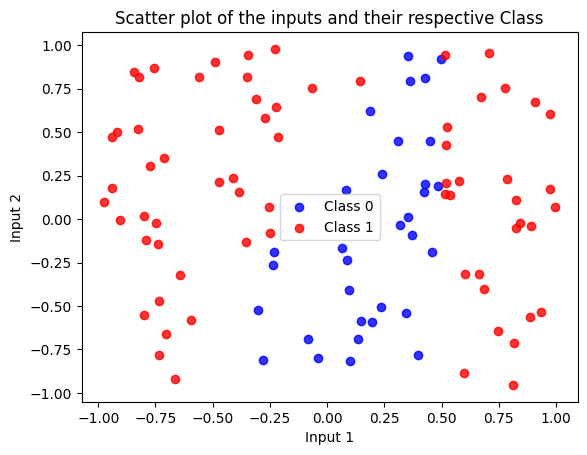

In [3]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed((42))

data = np.loadtxt("2d_classification_multiple_neurons.csv", delimiter=",")
input1 = data[:, 0]
input2 = data[:, 1]
labels = data[:, 2]

for class_value, color, label in zip([0, 1], ['blue', 'red'], ['Class 0', 'Class 1']):
    idx = labels == class_value
    plt.scatter(input1[idx], input2[idx], color=color, label=label, alpha=0.8)

plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("Scatter plot of the inputs and their respective Class")
plt.legend()
plt.show()

## Two layer multi neural network.

In [ ]:
class Neuron:
    def __init__(self, input_dim):
        self.weight_matrix = np.random.randn(input_dim)
        self.bias = np.random.randn()

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def squared_error(self, y_true: float, y_pred: float):
        return (y_true - y_pred) ** 2

    def output_function(self, x):
        return self.sigmoid(x @ self.weight_matrix + self.bias)

    def update(self, x, y_true: float, y_pred: float, eta):
        dE_dy_pred = self.dE_dy_pred(y_true, y_pred)
        dy_pred_dw = self.dy_pred_dw(x, y_pred)
        dy_pred_db = self.dy_pred_db(y_pred)

        dE_dw = dE_dy_pred * dy_pred_dw
        dE_db = dE_dy_pred * dy_pred_db

        self.weight_matrix -= eta * dE_dw
        self.bias -= eta * dE_db

    def dE_dy_pred(self, y_true, y_pred):
        return -2 * (y_true - y_pred)

    def dy_pred_dw(self, x, y_pred):
        return y_pred * (1 - y_pred) * x

    def dy_pred_db(self, y_pred):
        return y_pred * (1 - y_pred)




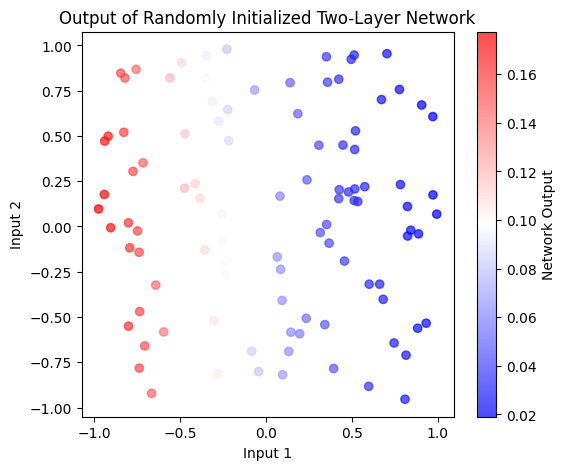

In [ ]:
N = 4

first_layer = [Neuron(input_dim=2) for _ in range(N)]
second_layer = Neuron(input_dim=N)

def forward(x):
    first_outputs = np.array([neuron.output_function(x) for neuron in first_layer])
    final_output = second_layer.output_function(first_outputs)
    return final_output

inputs = np.column_stack((input1, input2))
outputs = np.array([forward(x) for x in inputs])
plt.figure(figsize=(6, 5))
plt.scatter(data[:, 0], data[:, 1], c=outputs, cmap='bwr', alpha=0.7)
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("Output of Randomly Initialized Two-Layer Network")
plt.colorbar(label="Network Output")
plt.show()

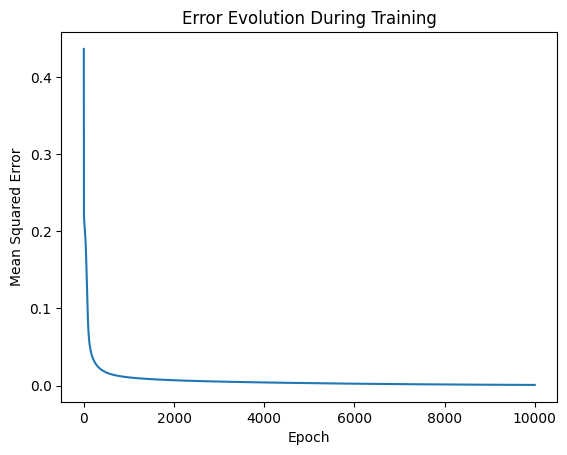

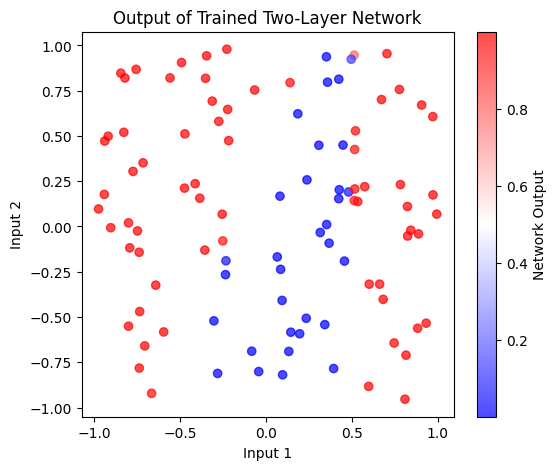

In [ ]:
learning_rate = 0.1
n_epochs = 10000
errors = []

for epoch in range(n_epochs):
    total_error = 0
    for x, y_true in zip(inputs, labels):
        # Forward pass
        y1 = np.array([neuron.output_function(x) for neuron in first_layer]) 
        y_pred = second_layer.output_function(y1)

        error = (y_true - y_pred) ** 2
        total_error += error

        # Gradients for output neuron
        dE_dy_pred = -2 * (y_true - y_pred)
        dy_pred_dz = y_pred * (1 - y_pred)  # sigmoid derivative
        delta = dE_dy_pred * dy_pred_dz     # scalar

        # Update output neuron weights and bias
        second_layer.weight_matrix -= learning_rate * delta * y1
        second_layer.bias -= learning_rate * delta

        # Backpropagate to first layer
        for i, neuron in enumerate(first_layer):
            # For each neuron in the first layer
            y1_i = y1[i]
            w_out_i = second_layer.weight_matrix[i]
            # Gradient for first layer neuron output
            dE_dy1 = delta * w_out_i
            dy1_dz1 = y1_i * (1 - y1_i)
            delta1 = dE_dy1 * dy1_dz1

            neuron.weight_matrix -= learning_rate * delta1 * x
            neuron.bias -= learning_rate * delta1

    errors.append(total_error / len(inputs))

plt.figure()
plt.plot(errors)
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Error Evolution During Training")
plt.show()

outputs_trained = np.array([forward(x) for x in inputs])
plt.figure(figsize=(6, 5))
plt.scatter(data[:, 0], data[:, 1], c=outputs_trained, cmap='bwr', alpha=0.7)
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("Output of Trained Two-Layer Network")
plt.colorbar(label="Network Output")
plt.show()